# Climate time series data

Content
The Dataset contains weather data from 1 January 2013 to 24 April 2017 in the city of Delhi, India. The 4 parameters in the dataset are
meantemp, humidity, wind_speed, meanpressure.

This dataset has been collected from Weather Undergroud API. 


In [70]:
import pandas as pd
import numpy as np

In [ ]:
df_train = pd.read_csv('DailyDelhiClimateTrain.csv')
df_test = pd.read_csv('DailyDelhiClimateTest.csv')

In [72]:
df_train.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


In [73]:
df_test.head()

,date,meantemp,humidity,wind_speed,meanpressure
0,2017-01-01,15.913043,85.869565,2.743478,59.000000
1,2017-01-02,18.500000,77.222222,2.894444,1018.277778
2,2017-01-03,17.111111,81.888889,4.016667,1018.333333
3,2017-01-04,18.700000,70.050000,4.545000,1015.700000
4,2017-01-05,18.388889,74.944444,3.300000,1014.333333


Number of observations

In [74]:
df_train.shape

(1462, 5)

In [75]:
df_test.shape

(114, 5)

Number of missing values

In [76]:
df_train.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

In [77]:
df_test.isna().sum()

date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

OK so we have 1462 training observations and 114 test observations. Let's train some time series models on the training data and use it to predict the test data on mean temperature.

### ARIMA

ARIMA (AutoRegressive Integrated Moving Average) is a classical statistical time series model used for forecasting univariate data. It combines three key components: AutoRegression (AR), which models the relationship between an observation and its past values; Integration (I), which differences the series to make it stationary; and Moving Average (MA), which models the relationship between an observation and past forecast errors. The model is defined by three parameters (p, d, q) representing the AR order, differencing order, and MA order. ARIMA assumes linear relationships and works best when the series is stationary (or can be made stationary through differencing).

Pros:

- Interpretable and theoretically well-grounded

- Works well for small-to-medium datasets

- Strong baseline model for many forecasting problems

Cons:

- Assumes linear structure

- Requires stationarity

- Manual parameter tuning can be challenging

- Not ideal for highly nonlinear or complex seasonal patterns (without SARIMA extension)

Let's first check the time series to see whether its stationary.

In [78]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_train['meantemp'])
print('ADF p-value:', result[1])

ADF p-value: 0.27741213723016056


In [79]:
import plotly.express as px

In [80]:
px.line(df_train, 
        x='date', 
        y='meantemp')

the time series exhibit clear seasonal patterns ranging from a low temperature of 10 degrees in winter and a high of nearly 40 degrees in summer. Thus we fail to reject the unit-root null hypothesis — meaning the original series is non-stationary. Let's difference the time series and check the daily differenced series.

In [81]:
df_diff = df_train['meantemp'].diff().dropna()
result = adfuller(df_diff)
print('ADF p-value:', result[1])

ADF p-value: 2.764863137594368e-29


In [82]:
df_diff = df_train.copy()
df_diff["meantemp"] = df_diff["meantemp"].diff()

df_diff = df_diff.dropna()

px.line(df_diff, x="date", y="meantemp")

The above time series look more suitable for using the ARIMA model. Let's instantiate a model. In the ARIMA we have three parameters. Above we have determined that d is 1, i.e. we have differenced the time series one time to make it stationary. Let's find the number of suitable AR and MA lags.

p → number of autoregressive (AR) lags

d → number of differences needed for stationarity

q → number of moving average (MA) lags

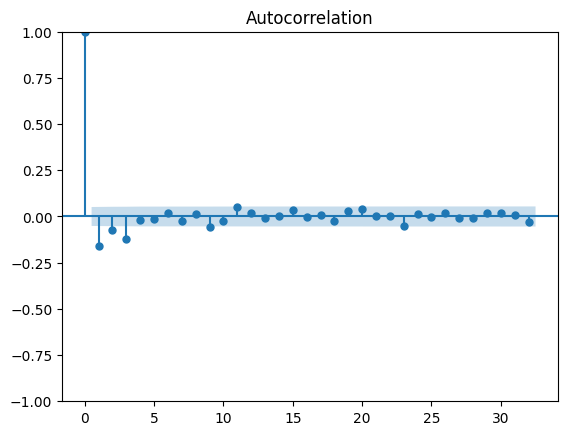

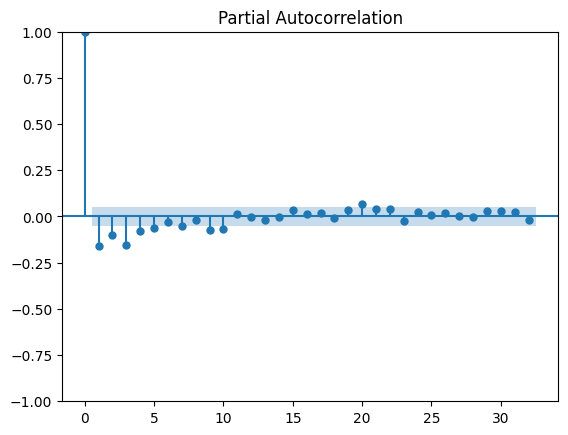

In [83]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plot_acf(df_diff['meantemp'])
plot_pacf(df_diff['meantemp'])
plt.show()

The Autocorrelation Function helps in choosing a suitable q parameter and the Partial Autocorrelation helps in choosing a suitable p parameter. 

The q-parameter seems to be more easily determined at 3 since the first three observations are located outside the confidence interval.

On the other hand, the first 5 observations for the partial autocorrelation is outside the confidence interval, but then also 7,9, 10, so it is more ambiguous where a proper cutoff is. Let's try a few and use the AIC to see which fairs the best.


In [84]:
from statsmodels.tsa.arima.model import ARIMA
d=1
for q in range(4):
    for p in range(5, 11):
        try:
            model = ARIMA(df_train['meantemp'], order=(p,d,q))
            results = model.fit()
            print(f"ARIMA({p},{d},{q}) AIC:", results.aic)
        except:
            continue

ARIMA(5,1,0) AIC: 5552.29743737714
ARIMA(6,1,0) AIC: 5552.773463965537
ARIMA(7,1,0) AIC: 5550.928654611672
ARIMA(8,1,0) AIC: 5552.475898379125
ARIMA(9,1,0) AIC: 5546.185812910753
ARIMA(10,1,0) AIC: 5541.05310297903
ARIMA(5,1,1) AIC: 5543.906205327584
ARIMA(6,1,1) AIC: 5545.858817827244
ARIMA(7,1,1) AIC: 5546.033331721095
ARIMA(8,1,1) AIC: 5547.650313678165
ARIMA(9,1,1) AIC: 5543.548105963062
ARIMA(10,1,1) AIC: 5542.876469779153
ARIMA(5,1,2) AIC: 5545.550670818986
ARIMA(6,1,2) AIC: 5547.513242980844
ARIMA(7,1,2) AIC: 5548.167464441102
ARIMA(8,1,2) AIC: 5549.962456227646
ARIMA(9,1,2) AIC: 5544.691746508664
ARIMA(10,1,2) AIC: 5544.869992549423


c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



ARIMA(5,1,3) AIC: 5519.00534980816


c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



ARIMA(6,1,3) AIC: 5548.420945594889


c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



ARIMA(7,1,3) AIC: 5545.387782853319


c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



ARIMA(8,1,3) AIC: 5550.07219368951
ARIMA(9,1,3) AIC: 5544.552417904065
ARIMA(10,1,3) AIC: 5546.313764880895


AIC (Akaike Information Criterion) is a metric used to compare models and select the best one among competing alternatives. Better fit → higher likelihood → lower AIC. 

AIC is defined as 
Where: 2k - 2ln(L)

k = number of parameters (complexity penalty)

L = likelihood (how well the model fits)

We select the lower AIC because that minimizes the model’s information loss relative to the true (unknown) data-generating process.

Lower AIC → less information lost

Higher AIC → more unnecessary complexity or worse fit

Let's go with an ARIMA(5,1,3) where p=5 uses the last 5 lags of the series (autoregressive terms), d=1 differences the series once to make it more stationary, and q=3 uses 3 lags of forecast errors (moving-average terms) that generated an AIC of 5518.9.

In [85]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Assume df_train and df_test already exist
# and contain a column named 'meantemp'

# Define ARIMA order (p, d, q)
order = (5,1,3)

# Fit model on training data
model_arima = ARIMA(df_train['meantemp'], order=order)
model_fit = model_arima.fit()

# Forecast for length of test set
forecast_arima = model_fit.forecast(steps=len(df_test))

# Evaluate performance
mse = mean_squared_error(df_test['meantemp'], forecast_arima)
rmse = np.sqrt(mse)

print("RMSE:", rmse)

# Optional: create comparison dataframe
results = pd.DataFrame({
    "Actual": df_test['meantemp'].values,
    "Forecast": forecast_arima.values
})

print(results.head())

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



RMSE: 15.952405251623867
      Actual   Forecast
0  15.913043  11.287675
1  18.500000  11.991631
2  17.111111  12.554202
3  18.700000  12.827402
4  18.388889  13.052466


c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [86]:
df_train["date"] = pd.to_datetime(df_train["date"])
df_test["date"] = pd.to_datetime(df_test["date"])

# Align forecast to test dates
forecast_series = pd.Series(forecast_arima.values, index=df_test["date"], name="Forecast")

# Build long-form dataframe for px.line
plot_df = pd.concat([
    df_train[["date", "meantemp"]].assign(Series="Train"),
    df_test[["date", "meantemp"]].assign(Series="Test"),
    forecast_series.reset_index().rename(columns={"index": "date", "Forecast": "meantemp"}).assign(Series="Forecast")
], ignore_index=True)

fig = px.line(
    plot_df,
    x="date",
    y="meantemp",
    color="Series",
    title="ARIMA Forecast vs Train and Test"
)
fig.show()

In [120]:
forecast_series.head()

date
2017-01-01    11.287675
2017-01-02    11.991631
2017-01-03    12.554202
2017-01-04    12.827402
2017-01-05    13.052466
Name: Forecast, dtype: float64

OK so this first baseline model performs poorly as it simply stretches out the training data time series using a short lookback window, it does not take into account the seasonal pattern and therefore the predicted series continues downward whereas the test data reverts back according to the seasonal pattern. Therefore we need to go for a more advanced model but lets first check the error of the model to have a baseline comparison.

In [87]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_arima = np.sqrt(mean_squared_error(df_test['meantemp'], forecast_arima))
print("Root mean squared error of ARIMA forecast to test data:", rmse_arima)

Root mean squared error of ARIMA forecast to test data: 15.952405251623867


### ETS model

ExponentialSmoothing implements the Holt–Winters exponential smoothing family of forecasting methods. It models a time series using weighted averages of past observations, where more recent observations receive exponentially higher weight. Depending on configuration, it can include a level component (simple exponential smoothing), a trend component (Holt’s method), and a seasonal component (additive or multiplicative). The model updates these components recursively over time and is especially well suited for short-term forecasting of series with stable trend and/or seasonality.

Compared to other time series models like ARIMA or SARIMA, exponential smoothing is generally more component-driven and state-based, focusing on decomposing the series into level, trend, and seasonality rather than modeling autocorrelation structures explicitly. ARIMA-type models describe the statistical dependence between lagged observations and errors, making them more flexible for complex autocorrelation patterns but also more parameter-intensive and assumption-heavy. In contrast, Holt–Winters is often simpler to tune, computationally efficient, and strong for practical business forecasting when patterns are relatively smooth and persistent, though it may struggle with highly irregular dynamics or strong external drivers.

In [88]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

In [89]:
seasonal_periods = 365

ets_model = ExponentialSmoothing(
    df_train["meantemp"],
    trend="add",
    seasonal="add",
    seasonal_periods=seasonal_periods,
    initialization_method="estimated"
)

ets_fit = ets_model.fit()

# Forecast
ets_forecast = ets_fit.forecast(steps=len(df_test))

# Align index
ets_forecast.index = df_test.index

In [90]:
ets_forecast = ets_forecast.to_frame().join(df_test["date"])
ets_forecast.columns = ["meantemp", "date"]

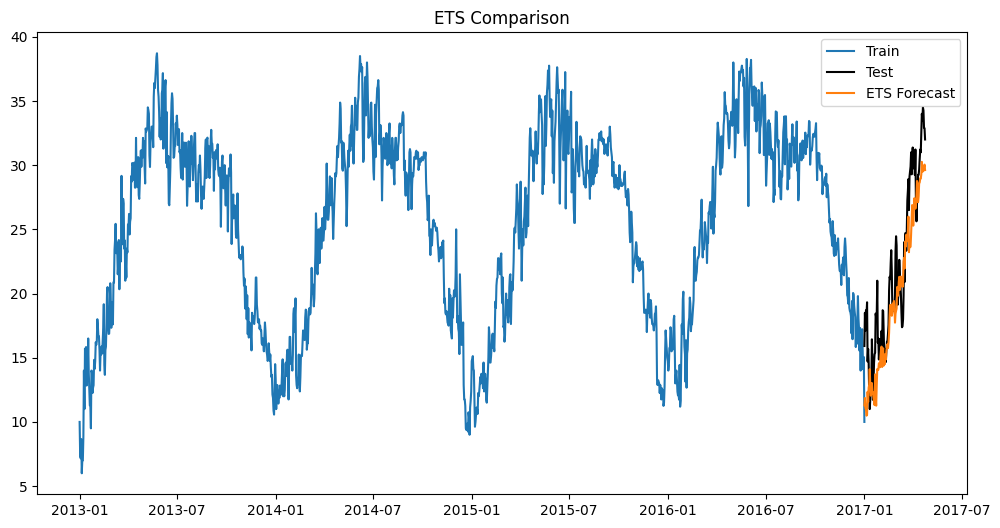

In [91]:
plt.figure(figsize=(12,6))

plt.plot(df_train.date, df_train["meantemp"], label="Train")
plt.plot(df_test.date, df_test["meantemp"], label="Test", color="black")

plt.plot(ets_forecast.date, ets_forecast["meantemp"], label="ETS Forecast")
#plt.plot(ucm_forecast.index, ucm_forecast, label="UCM Forecast")

plt.legend()
plt.title("ETS Comparison")
plt.show()

In [92]:
rmse_ets = np.sqrt(mean_squared_error(df_test['meantemp'], ets_forecast['meantemp']))
print("Root mean squared error of ETS forecast to test data:", rmse_ets)

Root mean squared error of ETS forecast to test data: 3.3259017528934636


### FB Prophet

Lets next use the FB Prophet model, which uses an additive, interpretable decomposition framework to forecast timeseries, including a trend component, seasonality (yearly/weekly/daily), holiday effects (optional), and noise.

Trend: piecewise linear (or logistic) trend with regularization to prevent overfitting.

Seasonality via Fourier series: handles smooth seasonal patterns well (e.g., “low in Jan/Dec, high in July”), even for long periods like 365 days.

Robust to missing data and outliers (in practice often easier than SARIMAX).

In [93]:
from sklearn.metrics import mean_squared_error
from prophet import Prophet

# --- Prepare data in Prophet format: ds (datetime) and y (target) ---
train = df_train.copy()
test = df_test.copy()

train["date"] = pd.to_datetime(train["date"])
test["date"] = pd.to_datetime(test["date"])

prophet_train = train.rename(columns={"date": "ds", "meantemp": "y"})[["ds", "y"]]
prophet_test  = test.rename(columns={"date": "ds", "meantemp": "y"})[["ds", "y"]]

# --- Fit Prophet ---
m = Prophet(
    yearly_seasonality=True,   # important for your case
    weekly_seasonality=True,   # often safe for daily data (can set False if not needed)
    daily_seasonality=False,   # usually not needed for daily weather (turn on if intra-week patterns)
    seasonality_mode="additive",
    changepoint_prior_scale=0.05  # lower = smoother trend, higher = more flexible
)

m.fit(prophet_train)

# --- Forecast exactly the test dates ---
future = prophet_test[["ds"]]
fcst = m.predict(future)

# Prophet output includes yhat, yhat_lower, yhat_upper
y_pred = fcst["yhat"].values
y_true = prophet_test["y"].values

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print("RMSE:", rmse)

# --- Plot: Train + Test + Forecast ---
plot_df = pd.concat([
    prophet_train.rename(columns={"y": "value"}).assign(Series="Train"),
    prophet_test.rename(columns={"y": "value"}).assign(Series="Test"),
    pd.DataFrame({"ds": prophet_test["ds"], "value": y_pred, "Series": "Forecast"})
], ignore_index=True)

fig = px.line(plot_df, x="ds", y="value", color="Series", title="Prophet: Train vs Test vs Forecast")
fig.show()

16:50:08 - cmdstanpy - INFO - Chain [1] start processing
16:50:08 - cmdstanpy - INFO - Chain [1] done processing


RMSE: 2.670004815377171


In [124]:
fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-01,27.531065,11.974276,17.039971,27.531065,27.531065,-13.168318,-13.168318,-13.168318,-0.195063,-0.195063,-0.195063,-12.973255,-12.973255,-12.973255,0.0,0.0,0.0,14.362747
1,2017-01-02,27.533981,11.942154,17.190030,27.533981,27.533981,-12.960709,-12.960709,-12.960709,-0.010844,-0.010844,-0.010844,-12.949865,-12.949865,-12.949865,0.0,0.0,0.0,14.573271
2,2017-01-03,27.536897,12.080968,17.281413,27.536897,27.536897,-12.877177,-12.877177,-12.877177,0.034058,0.034058,0.034058,-12.911235,-12.911235,-12.911235,0.0,0.0,0.0,14.659719
3,2017-01-04,27.539812,12.061735,17.352687,27.539812,27.539812,-12.713036,-12.713036,-12.713036,0.146275,0.146275,0.146275,-12.859310,-12.859310,-12.859310,0.0,0.0,0.0,14.826777
4,2017-01-05,27.542728,12.323413,17.510639,27.542728,27.542728,-12.728918,-12.728918,-12.728918,0.067163,0.067163,0.067163,-12.796081,-12.796081,-12.796081,0.0,0.0,0.0,14.813811


In [94]:
rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred))
print("Root mean squared error of Prophet forecast to test data:", rmse_prophet)

Root mean squared error of Prophet forecast to test data: 2.670004815377171


### VAR model

Let's now run a VAR model.

VAR (Vector Autoregression) is a multivariate time series model that captures how multiple variables evolve together over time.

Instead of modeling one variable at a time (like ARIMA), VAR models all variables in the system simultaneously.

VAR assumes that each variable depends on its own past values and the past values of all the other variables.

We are particularly interested in modelling meantemp, now also using humidity, wind speed and mean pressure.

We will also set up an impulse response function (IRF) which shows how a sudden shock in one variable affect the other variables over time.

For example it illustrates what happens to temperature if wind speed suddenly increases? How long does the effect last? Does it amplify or die out?

The IRF traces the path of the system after a one standard deviation shock to one variable.

In [95]:
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt

# Copy data
df = df_train.copy()

# Ensure datetime
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# Keep only numeric variables
df_var = df[["meantemp", "humidity", "wind_speed", "meanpressure"]]

In [96]:
df_var_diff = df_var.diff().dropna()

In [97]:
model = VAR(df_var_diff)

lag_results = model.select_order(maxlags=15)
print(lag_results.summary())

# Choose lag based on AIC
p = lag_results.aic
print("Selected lag (AIC):", p)

c:\Users\Gaming\miniconda3\envs\ai\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.



 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        18.85       18.86   1.532e+08       18.85
1        18.41       18.48   9.889e+07       18.44
2        18.16       18.29   7.688e+07       18.21
3        17.99       18.18   6.528e+07       18.07
4        17.92      18.16*   6.033e+07       18.01
5        17.86       18.17   5.728e+07       17.98
6        17.84       18.20   5.588e+07      17.97*
7        17.82       18.24   5.476e+07       17.98
8        17.82       18.30   5.462e+07       18.00
9        17.80       18.34   5.366e+07       18.00
10       17.79       18.38   5.301e+07       18.01
11      17.78*       18.44  5.273e+07*       18.03
12       17.79       18.51   5.322e+07       18.06
13       17.79       18.57   5.333e+07       18.08
14       17.79       18.63   5.342e+07       18.10
15       17.78       18.68   5.297e+07       18.12
-------------------------------

OK the AIC shows that 11 lags to the VAR model is the most feasiblei.e. VAR(11).

Below shows all equation results for modelling each variable, but we are interested in mean temperature which is the first set of results.

In [98]:
var_model = model.fit(p)

print(var_model.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 23, Feb, 2026
Time:                     16:51:17
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    18.4374
Nobs:                     1450.00    HQIC:                   18.0266
Log likelihood:          -20941.8    FPE:                5.28048e+07
AIC:                      17.7820    Det(Omega_mle):     4.67284e+07
--------------------------------------------------------------------
Results for equation meantemp
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.000463         0.041797            0.011           0.991
L1.meantemp             -0.185976         0.035808           -5.194           0.000
L1.humidity              0.009695         0.0

In [99]:
lag_order = var_model.k_ar

# Get last observations from training
forecast_input = df_var_diff.values[-lag_order:]

forecast = var_model.forecast(y=forecast_input, steps=len(df_test))

forecast_df = pd.DataFrame(
    forecast,
    index=df_test["date"],
    columns=df_var_diff.columns
)

In [100]:
last_train_level = df_var.iloc[-1]

forecast_level = forecast_df.cumsum() + last_train_level

In [101]:
meantemp_forecast = forecast_level["meantemp"]

In [102]:
df_train["date"] = pd.to_datetime(df_train["date"])
df_test["date"] = pd.to_datetime(df_test["date"])

# Build long-form dataframe
plot_df = pd.concat([
    df_train[["date", "meantemp"]].assign(Series="Train"),
    df_test[["date", "meantemp"]].assign(Series="Test"),
    forecast_level["meantemp"]
        .rename("meantemp")
        .reset_index()
        .rename(columns={"index": "date"})
        .assign(Series="Forecast")
], ignore_index=True)

fig = px.line(
    plot_df,
    x="date",
    y="meantemp",
    color="Series",
    title="Train vs Test vs VAR Forecast"
)

fig.show()

In [104]:
rmse_var = np.sqrt(mean_squared_error(df_test["meantemp"], forecast_level["meantemp"]))
print("Root mean squared error of VAR forecast to test data:", rmse_var)

Root mean squared error of VAR forecast to test data: 10.675244211417882


The forecast initially exhibits some short-run oscillations due to the dynamic interactions among the variables captured by the VAR model. These early fluctuations reflect the propagation of recent shocks and lagged cross-effects within the system. However, because the VAR is estimated in stationary form, shocks have only temporary effects. As the forecast horizon increases and no new shocks are introduced, the predicted values gradually converge toward the system’s long-run equilibrium (mean), resulting in a flattening of the forecast path after roughly 20 days. This behavior is characteristic of stable VAR models and reflects mean-reverting dynamics rather than sustained trend behavior since it is modelled on differenced series.

We can examine the effects of the variables on mean temperature as well.

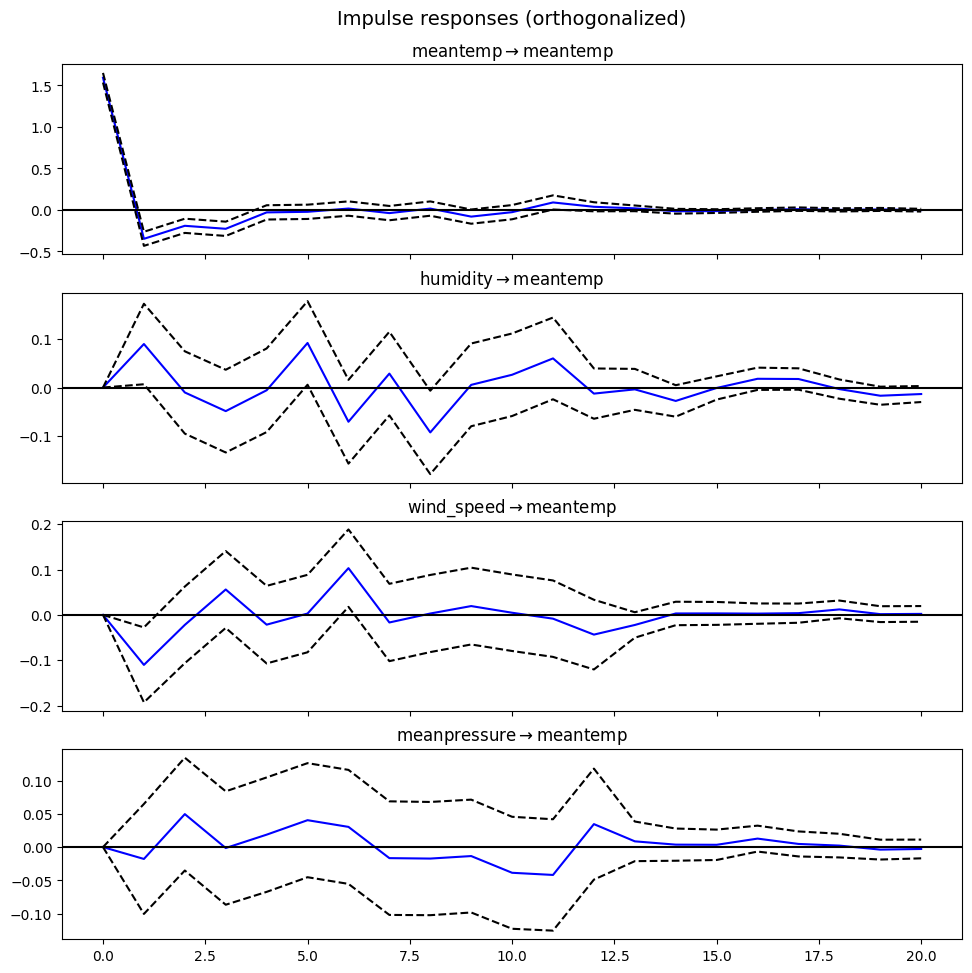

In [103]:
irf = var_model.irf(20)  # 20 periods ahead

irf.plot( response="meantemp", orth=True)
plt.show()

The impulse response analysis largely indicates a lack of statistically significant dynamic effects of humidity, wind speed, and mean pressure on mean temperature. The only notable short-run effect is a negative response of temperature to a wind speed shock at horizon one, which dissipates quickly. Additionally, temperature exhibits short-term mean reversion following its own shock, as the effect reverses at the next horizon and rapidly converges back to zero.

### Machine learning models

OK lets now move from classical statics to machine learning. We will test three different models used to predict time series.

Random Forest (RF) is an ensemble of decision trees trained in parallel using bagging (bootstrap samples) and random feature selection at each split. Each tree is a high-variance model; averaging many trees reduces variance, making RF stable and a great first baseline. It usually performs well with minimal tuning, but it can struggle to extrapolate trends and can be less accurate than boosting on structured forecasting features.

LightGBM and XGBoost are both gradient boosting models: they build trees sequentially, where each new tree learns to correct the errors of the previous ensemble. Boosting typically beats RF for tabular forecasting features (lags/rollings/calendar variables) because it optimizes a loss function directly. LightGBM is usually faster and more memory-efficient (histogram-based splits, leaf-wise growth), often excellent on medium/large datasets. XGBoost is very robust and widely used, with strong regularization options and solid performance; it can be a bit slower than LightGBM depending on settings but is very reliable.

Unlike traditional statistical time series models such as ARIMA, SARIMA, or VAR, machine learning models like Random Forest, LightGBM, and XGBoost do not inherently understand temporal structure. Classical models are specifically designed for time series data and automatically incorporate lag dependence and, in some cases, trend and seasonality through their mathematical formulation. In contrast, machine learning models treat the data as standard tabular input. They do not recognize ordering in time or the meaning of a date variable unless we explicitly engineer features such as lagged values, rolling statistics, or calendar-based variables (e.g., month or day-of-year). Therefore, in ML-based forecasting, the temporal dynamics must be manually encoded into the feature set before training the model.

Lets encode some features that the models can use which uses lags of target and other variables, rolling day statistics and calendar features from the date column

In [105]:
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor

# -----------------------
# 1) Feature engineering
# -----------------------
def make_features(df, target_col="meantemp", lags=(1,2,3,7,14), rolls=(3,7,14)):
    """
    Create time-series ML features without leakage:
    - lag features: shifted target and other variables
    - rolling stats computed on shifted target (past only)
    - calendar features from date
    """
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").set_index("date")

    # Calendar features
    df["dow"] = df.index.dayofweek
    df["month"] = df.index.month
    df["dayofyear"] = df.index.dayofyear

    # Cyclical encoding for yearly seasonality
    df["sin_doy"] = np.sin(2*np.pi*df["dayofyear"]/365.25)
    df["cos_doy"] = np.cos(2*np.pi*df["dayofyear"]/365.25)

    # Lags for target and predictors
    base_cols = [target_col, "humidity", "wind_speed", "meanpressure"]
    for col in base_cols:
        for L in lags:
            df[f"{col}_lag{L}"] = df[col].shift(L)

    # Rolling stats for target (use shifted target to avoid leakage)
    y_shift = df[target_col].shift(1)
    for w in rolls:
        df[f"{target_col}_rollmean{w}"] = y_shift.rolling(w).mean()
        df[f"{target_col}_rollstd{w}"]  = y_shift.rolling(w).std()

    return df


In [106]:

# -----------------------
# 2) Build a single dataset (safe) then split
# -----------------------
# Concatenate train + test so that lag features for early test rows can use the end of train
df_all = pd.concat([df_train, df_test], axis=0, ignore_index=True)
feat_all = make_features(df_all)

# Split back using the original test dates
test_dates = pd.to_datetime(df_test["date"])
train_dates = pd.to_datetime(df_train["date"])

feat_train = feat_all.loc[train_dates.min():train_dates.max()].copy()
feat_test  = feat_all.loc[test_dates.min():test_dates.max()].copy()

# Drop rows with NaNs created by lags/rollings
# (This will typically remove the first max(lag, roll) rows of the *train* portion)
target = "meantemp"
feature_cols = [c for c in feat_train.columns if c != target]

feat_train = feat_train.dropna(subset=feature_cols + [target])
feat_test  = feat_test.dropna(subset=feature_cols)  # target exists in df_test but keep features clean

X_train = feat_train[feature_cols]
y_train = feat_train[target]

X_test = feat_test[feature_cols]
y_test = feat_test[target]  # assumes df_test has true meantemp for evaluation

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))



In [107]:
# -----------------------
# 3) Random Forest
# -----------------------
rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=2
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)



In [161]:
# -----------------------
# 4) LightGBM
# -----------------------
from lightgbm import LGBMRegressor
lgbm = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
lgbm.fit(X_train, y_train)
pred_lgbm = lgbm.predict(X_test)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004377 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8158
[LightGBM] [Info] Number of data points in the train set: 1449, number of used features: 34
[LightGBM] [Info] Start training from score 25.634847
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [157]:
# -----------------------
# 5) XGBoost
# -----------------------
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=42,
    objective="reg:squarederror",
    n_jobs=-1
)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)


In [110]:
import matplotlib.dates as mdates

df_train["date"] = pd.to_datetime(df_train["date"])
df_test["date"] = pd.to_datetime(df_test["date"])

# Align predictions with test feature index
rf_series = pd.Series(pred_rf, index=feat_test.index)
lgbm_series = pd.Series(pred_lgbm, index=feat_test.index)
xgb_series = pd.Series(pred_xgb, index=feat_test.index)

def format_year_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.get_xticklabels(), rotation=45)




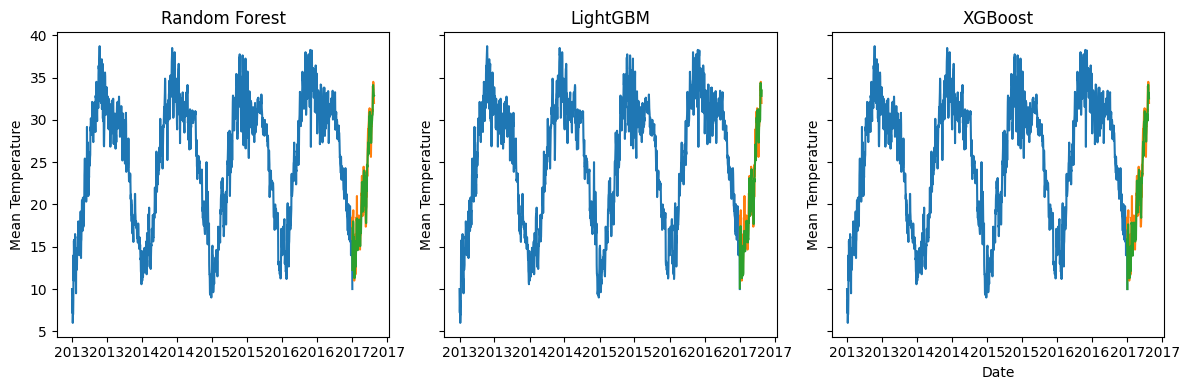

In [111]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

# --- Random Forest ---
axes[0].plot(df_train["date"], df_train["meantemp"])
axes[0].plot(df_test["date"], df_test["meantemp"])
axes[0].plot(rf_series.index, rf_series.values)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

axes[0].set_title("Random Forest")
axes[0].set_ylabel("Mean Temperature")

# --- LightGBM ---
axes[1].plot(df_train["date"], df_train["meantemp"])
axes[1].plot(df_test["date"], df_test["meantemp"])
axes[1].plot(lgbm_series.index, lgbm_series.values)
axes[1].set_title("LightGBM")
axes[1].set_ylabel("Mean Temperature")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- XGBoost ---
axes[2].plot(df_train["date"], df_train["meantemp"])
axes[2].plot(df_test["date"], df_test["meantemp"])
axes[2].plot(xgb_series.index, xgb_series.values)
axes[2].set_title("XGBoost")
axes[2].set_ylabel("Mean Temperature")
axes[2].set_xlabel("Date")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

In [113]:
rmse_rf = rmse(y_test, pred_rf)
rmse_lgbm = rmse(y_test, pred_lgbm)
rmse_xgb = rmse(y_test, pred_xgb)
print("Random Forest RMSE:", rmse_rf)
print("LightGBM RMSE:", rmse_lgbm)
print("XGBoost RMSE:", rmse_xgb)

Random Forest RMSE: 1.589909433621255
LightGBM RMSE: 1.6755676000274835
XGBoost RMSE: 1.5541671131375332


### Comparison of models

In [117]:
models = pd.Series({
    "ARIMA": rmse_arima,
    "ETS": rmse_ets,
    "Prophet": rmse_prophet,
    "VAR": rmse_var,
    "Random Forest": rmse_rf,
    "LightGBM": rmse_lgbm,
    "XGBoost": rmse_xgb
})
display("Comparison of RMSE across models")
models

'Comparison of RMSE across models'

ARIMA            15.952405
ETS               3.325902
Prophet           2.670005
VAR              10.675244
Random Forest     1.589909
LightGBM          1.675568
XGBoost           1.554167
dtype: float64

In [150]:
actual_data = df_test.copy()
actual_data = actual_data.set_index("date")
actual_data = actual_data[['meantemp']]

In [138]:
arima_forecast= forecast_series.copy()

In [135]:
ets_forecast = ets_forecast.set_index("date")

In [142]:
var_forecast = meantemp_forecast.copy()

In [140]:
prophet_series = fcst[['ds', 'yhat']]
prophet_series = prophet_series.set_index("ds")


In [151]:
models = pd.concat([actual_data, arima_forecast, var_forecast, 
                    prophet_series, ets_forecast, rf_series, 
                    lgbm_series, xgb_series], axis=1)

In [152]:
models.columns = ["Actual", "ARIMA", "VAR", "Prophet", "ETS", "Random Forest", "LightGBM", "XGBoost"]

In [155]:
fig = px.line(models, x=models.index, y=["Actual", "ARIMA", "VAR", "Prophet", "ETS", "Random Forest", "LightGBM", "XGBoost"], 
        title="Comparison Across Models Against Test Data", markers=True)
fig.update_layout(yaxis_title="Temperature", xaxis_title="Date")


OK so we see the evolution of the actual test data in blue which oscillates a bit in an upward trend and we see the various models. As we see ARIMA and VAR models fair the worst while the others are much closer. In fact the three machine learning models, Random Forest, LightGBM and XGBoost, are closest to the actual data series. This illustrates the importance of testing out a variety of models and compare their forecasting ability and also understand their pros and limitations.